In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
sys.path.append('../')

import time
import numpy as np
from tqdm.auto import tqdm

from src.contextualsimilarity import ContSimInfo, Distances, train_cont
from src.utils import render_graph, render_plot
from src.utils import create_convex_graph, create_multi_class_clique

In [2]:
def render_graph(testg, node_size = 1000, pos = None, path = None):
    fig, ax = plt.subplots(figsize= (24,12))
    node_colors = [testg.nodes[node]['label'] for node in testg.nodes]
    if not pos:
        pos = nx.kamada_kawai_layout(testg)
        #pos = nx.spring_layout(testg)
    cmap = plt.cm.Accent
    nx.draw(
        testg, pos=pos, node_size=node_size, node_color = node_colors, 
        cmap = cmap, ax = ax, width = 0.1, edgecolors='black'
    )

    # sm = plt.cm.ScalarMappable(cmap=cmap)
    # cax = fig.add_axes([0.95, 0.1, 0.02, 0.8])
    # sm.set_array(node_colors)
    # cbar = plt.colorbar(sm, cax=cax)
    # cbar.set_label('Node Label')

    if path is not None:
        plt.savefig(path)

    plt.show()

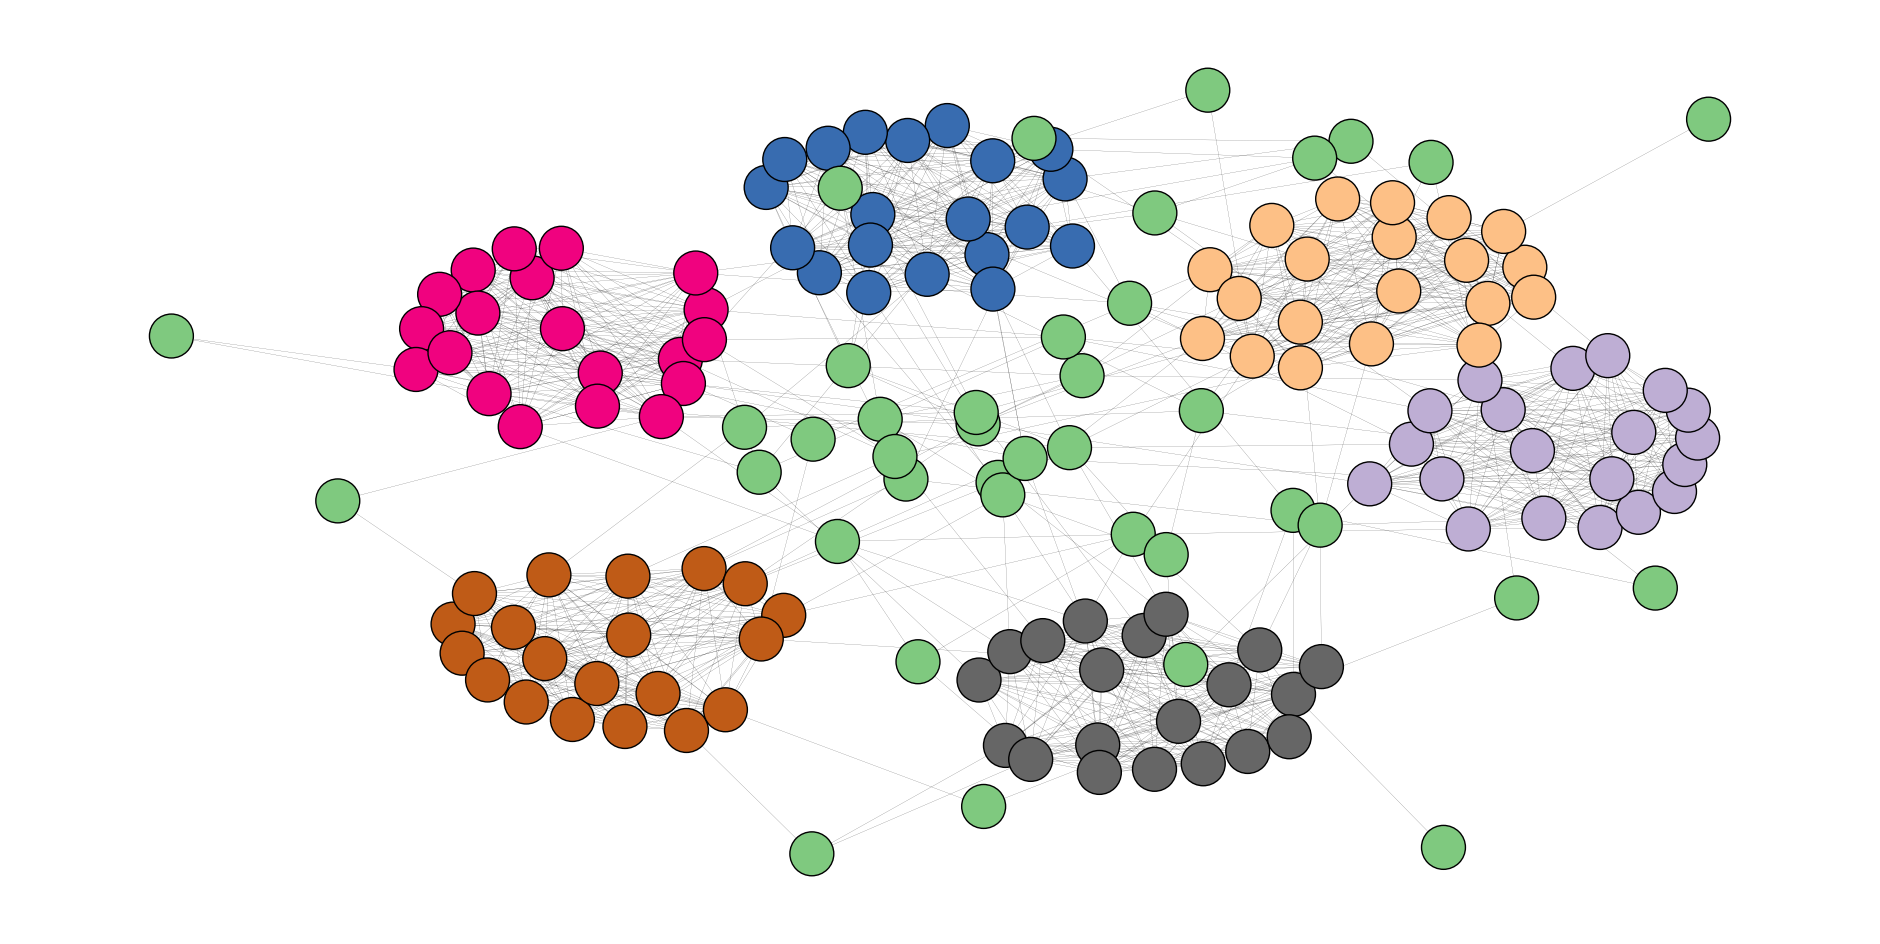

In [5]:
import networkx as nx

rand_inst = np.random.default_rng(42)
g = create_multi_class_clique(n_clique=20,classes=6, n_nodes_noise=40, rand_inst=rand_inst, shading = 0.3)
render_graph(g, path='./clique.pdf')

# Training all models

In [6]:
from tqdm.auto import tqdm
from src.vcbases import retrieve_interval_bases
from src.utils import compute_node_to_bases
from src.bandits import OSE4, train_bandit
from src.baseline_models import train_knn, train_perceptron, train_rst
from src.vcbases import retrieve_hier_bases, retrieve_ball_bases, retrieve_st_bases, train_model, retrieve_lvc_bases_peeling
from src.balls import BallDistances
from src.utils import create_gaussian_graph, render_graph
from src.GABA import GABA, train_gaba
from src.contextualsimilarity import ContSimInfo, Distances, train_cont
from src.exp3 import train_exp3

import random
import numpy as np
import pandas as pd
from collections import defaultdict
from utils import relabel_graph, relabel_nodes_id

time_temp = time.time()

epochs = 1

clique_points_list = [4,8,16]
noise_points_list_factor = [3,5]

input_list = []
for a in clique_points_list:
    for b in noise_points_list_factor:
        input_list.append((a, a * b))

seed_list = random.choices(list(range(1000)),k = 15)

rows_df = []
rows_names = []
plt_np_arr = {
    input_el : dict() for i,input_el in enumerate(input_list)
}

for ind,(node_clique, node_noise) in tqdm(enumerate(input_list), total=len(input_list), desc="Retrieving and training..."):
    # FIX GRAPH for each run
    testg = create_multi_class_clique(n_clique=node_clique, classes=4, n_nodes_noise = node_noise, rand_inst=rand_inst, shading = 1.0)
    
    # Retrieving balls
    balls = BallDistances(testg, initialize_sp=False, initialize_edp=False, initialize_pinv=False, disable = True)
    tolerance = 0.001
    d1_bases, n2b_d1 = retrieve_ball_bases(testg, balls.d1_ball_distance, disable=True)
    d2_bases, n2b_d2 = retrieve_ball_bases(testg, balls.d2_ball_distance, disable=True, log_balls = True)
    dinf_bases, n2b_dinf = retrieve_ball_bases(testg, balls.dinf_ball_distance, disable=True)
    lvc_bases, n2b_lvc = retrieve_lvc_bases_peeling(testg,disable=True)
    int_bases, n2b_int = retrieve_interval_bases(testg, disable = True)
    
    bases_list = [(d1_bases, n2b_d1, "D1"), 
                  (d2_bases, n2b_d2, "D2"), 
                  (dinf_bases, n2b_dinf, "D-INF"), 
                  (lvc_bases, n2b_lvc, "LVC"), 
                  (int_bases, n2b_int, "INT")]
    
    # Squared number of nodes (at least 2 times for each node)
    T = len(testg.nodes)*10
    print(T)
    K_classes = 4
    res_list = defaultdict(lambda : [])
    res_plot = defaultdict(lambda : [])
    
    for seed in tqdm(seed_list, desc="Epochs"):    
        ##############################################################################
        ######################### TRAINING ###########################################
        ##############################################################################
        loss_perc = .8
        verbose = False
        for base, n2b, name in bases_list:
            res, _ = train_bandit(testg, 
                base,
                n2b,
                T,
                K_classes,
                loss_percentage = loss_perc,
                seed = seed,
                verbose = verbose,
                name=name,
                disable_tqdm_train = True, debug = True)
            res_list[name] += [res[0]/T]
            res_plot[name] += [np.array(res[1])]
            
        res_gaba, _ = train_gaba(
            testg, 
            T, 
            K_classes + 1, 
            eta = 0.07,
            seed = seed, 
            loss_percentage = loss_perc,
            debug = True, verbose = verbose, disable_tqdm_train = True)
        res_list["GABA"] += [res_gaba[0]/T]
        res_plot["GABA"] += [np.array(res_gaba[1])]
        
        res_cbs, _ = train_cont(
            testg, 
            T, 
            K_classes + 1, 
            seed = seed, 
            loss_percentage = loss_perc,
            debug = True, verbose = verbose, disable_tqdm_train = True)
        res_list["CBSim"] += [res_cbs[0]/T]
        res_plot["CBSim"] += [np.array(res_cbs[1])]
        
        res_exp3, _ = train_exp3(
            testg, 
            T, 
            K_classes + 1, 
            seed = seed, 
            loss_percentage = loss_perc,
            debug = True, verbose = verbose, disable_tqdm_train = True)
        res_list["EXP3"] += [res_exp3[0]/T]
        res_plot["EXP3"] += [np.array(res_exp3[1])]

    rate_list = [np.mean(r_l) for _,r_l in res_list.items()]
    std_list = [np.std(r_l) for _,r_l in res_list.items()]
    
    for lab, plot in res_plot.items(): 
        plt_np_arr[(node_clique, node_noise)][lab] = plot
    
    rows_df += [rate_list]
    rows_names += [f'Mean{input_list[ind]}']
    rows_df += [std_list]
    rows_names += [f'Std{input_list[ind]}']

# Pandas dataframe res:
#base_model_names = res_list.keys()
#
#res_df = pd.DataFrame(columns=base_model_names)
#for ind,row in enumerate(rows_df):
#    res_df.loc[ind] = row
#    
#res_df.index = rows_names
#time_temp = time.time() - time_temp
##res_df.to_csv(f"{save_path_name}.csv", index=True)
##f.close()

Retrieving and training...:   0%|          | 0/6 [00:00<?, ?it/s]

280


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

360


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

...

Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

1120


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

1440


Epochs:   0%|          | 0/15 [00:00<?, ?it/s]

In [7]:
test_loaded_plot = (input_list, plt_np_arr)

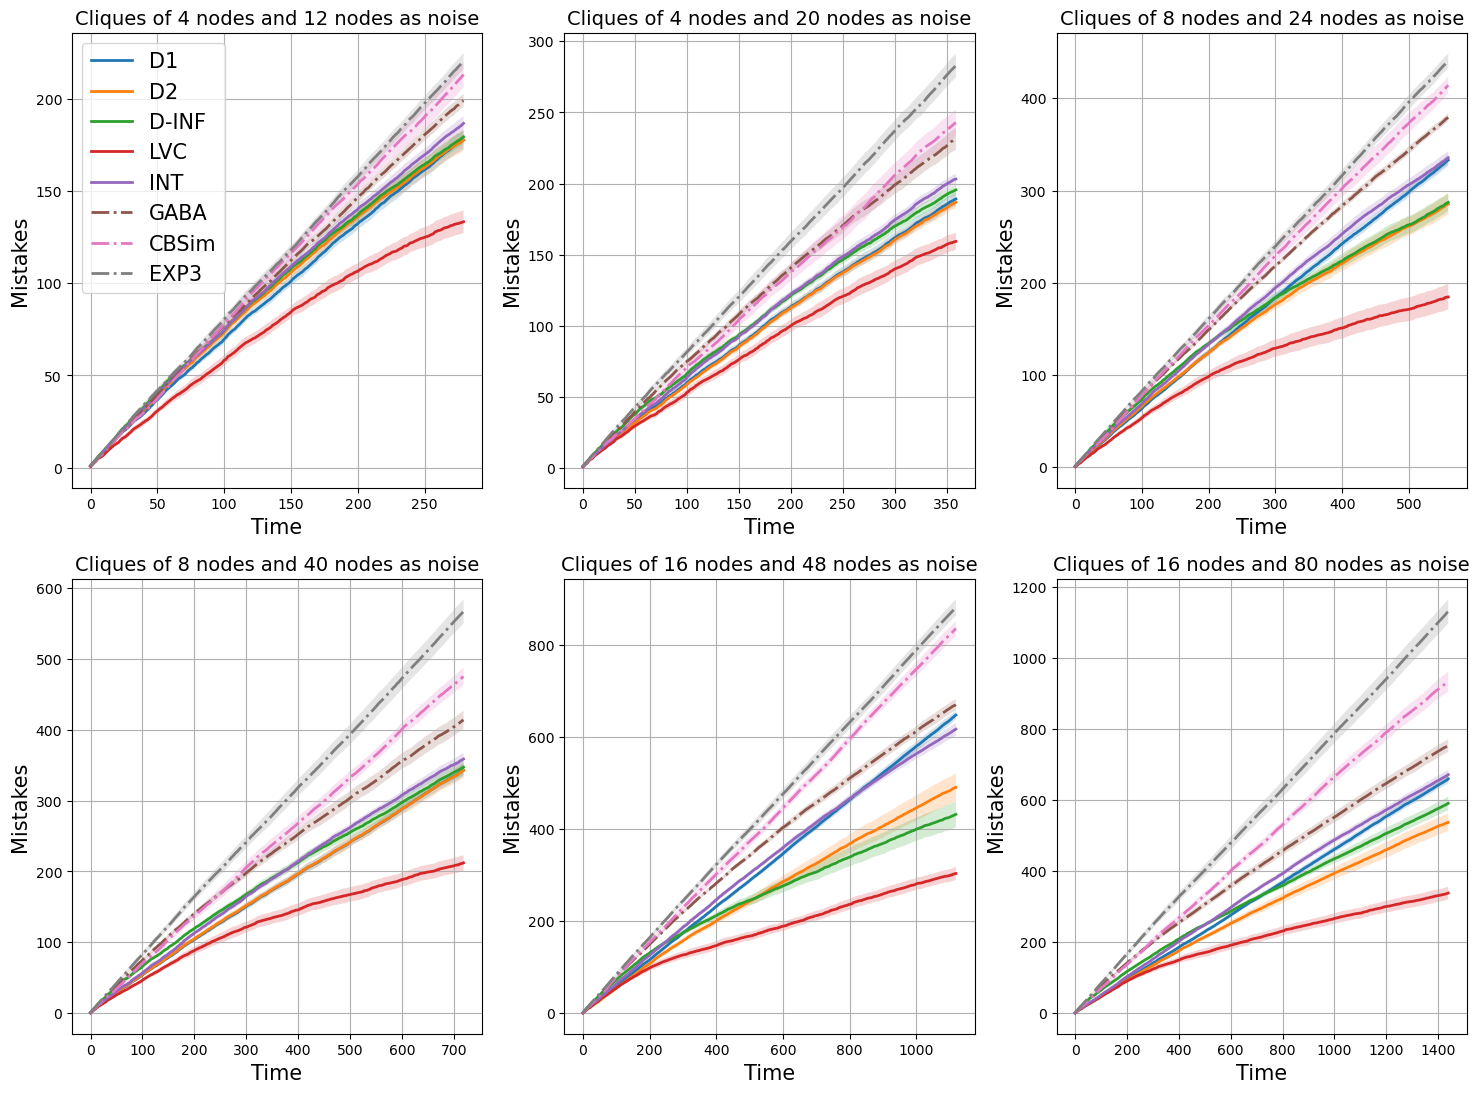

In [12]:
from src.utils import render_plot_CI

render_plot_CI('Clique', test_loaded_plot,2,3, figx=18, figy=13, save_fig=True, path = './results/clique/all_runs_clique.pdf')

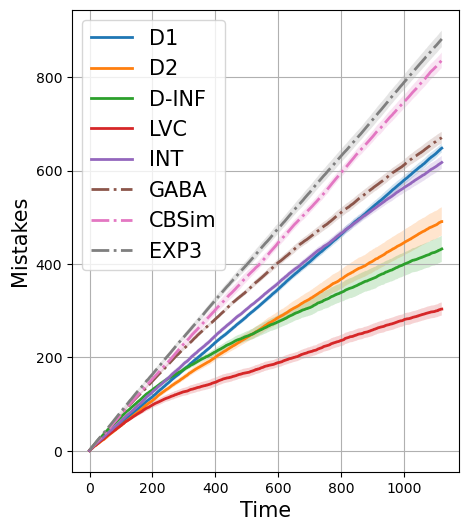

In [15]:
cora = plt_np_arr[(16,48)]

baselines = ['EXP3', 'GABA', 'CBSim']

fig, axs = plt.subplots(1, 1, figsize=(5, 6))
for sub_key, sub_data in cora.items():
    if sub_key in baselines:
        line =  'dashdot'
    else:
        line = 'solid'
    plot_data = np.mean(sub_data, axis = 0)
    axs.plot(plot_data, label=sub_key, linestyle = line, lw = 2)

    conf_int = np.std(sub_data, axis = 0) / np.sqrt(len(sub_data)) * 1.96
    axs.fill_between(np.arange(len(plot_data)), plot_data - conf_int, plot_data + conf_int, alpha=0.2)
plt.grid()
plt.xlabel('Time',fontsize=15)
plt.ylabel('Mistakes',fontsize=15) 
plt.legend(loc=2, fontsize=15)
fig.savefig("results/clique/clique_main_CI.pdf")